## **Deep Bidirectional LSTM Model using an embedding layer to learn embeddings**

### **Importing necessary libraries and Data Loading**

In [1]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load your train and test data
train_df = pd.read_csv(r"C:\Users\User\Downloads\train_data.csv")
test_df = pd.read_csv(r"C:\Users\User\Downloads\test_data.csv")

### **Tokenization Pipeline for Training and Testing Data**

In [2]:
# Optional: Rename 'Tweet' to 'Text' for clarity
train_df.rename(columns={'Tweet': 'Text'}, inplace=True)
test_df.rename(columns={'Tweet': 'Text'}, inplace=True)

# Extract texts and labels
X_train_text = train_df['Text'].astype(str)
y_train = train_df['Sentiment_Label']

X_test_text = test_df['Text'].astype(str)
y_test = test_df['Sentiment_Label']

# Tokenizer setup
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Padding
maxlen = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

# Convert labels to categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Print shapes for verification
print("Training Data:", X_train_pad.shape, y_train_cat.shape)
print("Testing Data:", X_test_pad.shape, y_test_cat.shape)

Training Data: (24000, 100) (24000, 3)
Testing Data: (6000, 100) (6000, 3)


### **Model Building**

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Define model parameters
vocab_size = 20000     # Same as num_words in tokenizer
embedding_dim = 128    # Size of embedding vector
input_length = 100     # Same as maxlen

# Build the model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(input_length,)))  # fixed line
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build and show summary
model.build(input_shape=(None, input_length))
model.summary()

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 100, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,704,387 (10.32 MB)

 Trainable params: 2,704,387 (10.32 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 47s 64ms/step - accuracy: 0.5280 - loss: 0.9391 - val_accuracy: 0.6983 - val_loss: 0.6895
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 45s 66ms/step - accuracy: 0.7736 - loss: 0.5521 - val_accuracy: 0.7379 - val_loss: 0.6294
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 44s 66ms/step - accuracy: 0.8531 - loss: 0.3707 - val_accuracy: 0.7437 - val_loss: 0.6526
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 45s 67ms/step - accuracy: 0.8997 - loss: 0.2727 - val_accuracy: 0.7429 - val_loss: 0.7689
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 45s 67ms/step - accuracy: 0.9286 - loss: 0.2026 - val_accuracy: 0.7350 - val_loss: 0.8747
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 46s 68ms/step - accuracy: 0.9493 - loss: 0.1494 - val_accuracy: 0.7258 - val_loss: 1.0343
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 46s 69ms/step - accuracy: 0.9659 - loss: 0.1038 - val_accuracy: 0.7242 - val_loss: 1.1006
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 46s 69ms/step - accuracy: 0.9737 - loss: 0.0824 - 

## Training and Validation Accuracy

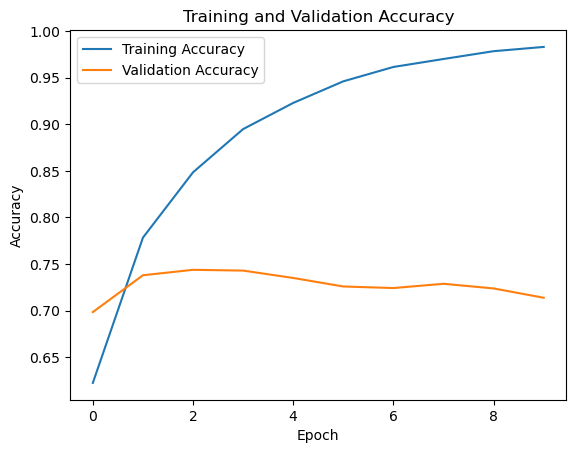

In [5]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

## Loss over epochs

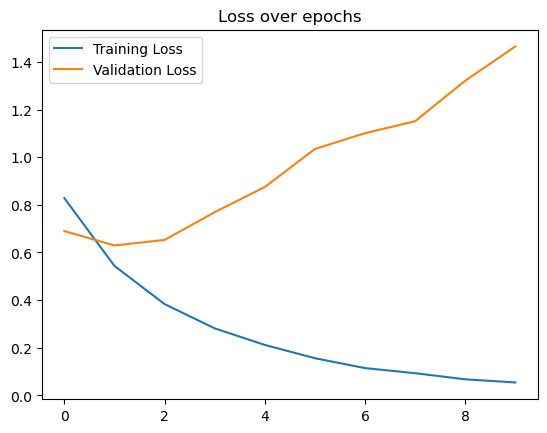

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

In [7]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9831481575965881
Final Validation Accuracy: 0.7137500047683716


In [8]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_cat, verbose=1)
print("Test Accuracy:", test_accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7050 - loss: 1.4716
Test Accuracy: 0.7111666798591614


## Training Data Check

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on padded test data
y_pred = model.predict(X_test_pad)
y_pred_classes = y_pred.argmax(axis=1)

# Get true class labels
y_true = y_test_cat.argmax(axis=1)

# Print classification report and confusion matrix
print("Classification Report")
print(classification_report(y_true, y_pred_classes))

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.77      0.65      0.71      2000
           1       0.59      0.73      0.65      2000
           2       0.82      0.75      0.79      2000

    accuracy                           0.71      6000
   macro avg       0.73      0.71      0.71      6000
weighted avg       0.73      0.71      0.71      6000



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Train True Labels
y_train_true = np.argmax(y_train_cat, axis=1)

# Predict on training data
y_train_pred_probs = model.predict(X_train_pad)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_train_true, y_train_pred)

# F1 Score from classification report
report = classification_report(y_train_true, y_train_pred, output_dict=True)
f1_positive = report.get("2", {}).get("f1-score", 0.0)
f1_negative = report.get("0", {}).get("f1-score", 0.0)

# Accuracy
train_accuracy = np.mean(y_train_pred == y_train_true)

# AUC Score (macro average)
auc_score = roc_auc_score(y_train_cat, y_train_pred_probs, multi_class='ovr', average='macro')

# Print Metrics Summary
print("Evaluation Summary of training data")
print(f"F1 Score (Positive): {f1_positive:.4f}")
print(f"F1 Score (Negative): {f1_negative:.4f}")
print(f"Training Accuracy  : {train_accuracy:.4f}")
print(f"AUC Score          : {auc_score:.4f}")

750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step
Evaluation Summary of training data
F1 Score (Positive): 0.9719
F1 Score (Negative): 0.9683
Training Accuracy  : 0.9637
AUC Score          : 0.9916


In [11]:
print("confusion Matrix")
print(conf_matrix)

confusion Matrix
[[7691  271   38]
 [ 151 7692  157]
 [  43  210 7747]]


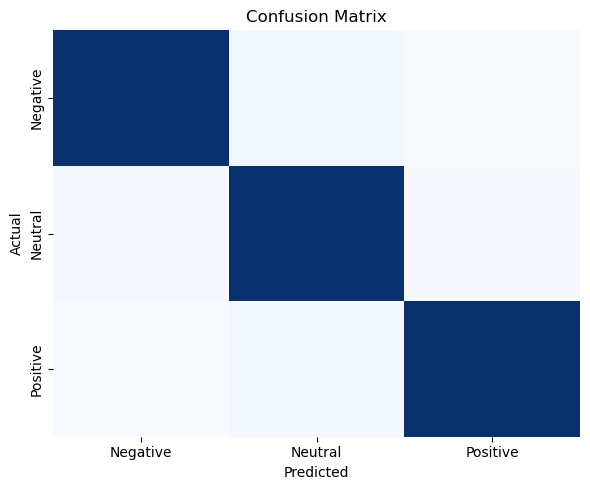

In [12]:
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, fmt='d', cmap='Blues', cbar=False, xticklabels=["Negative", "Neutral", "Positive"],yticklabels=["Negative", "Neutral", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

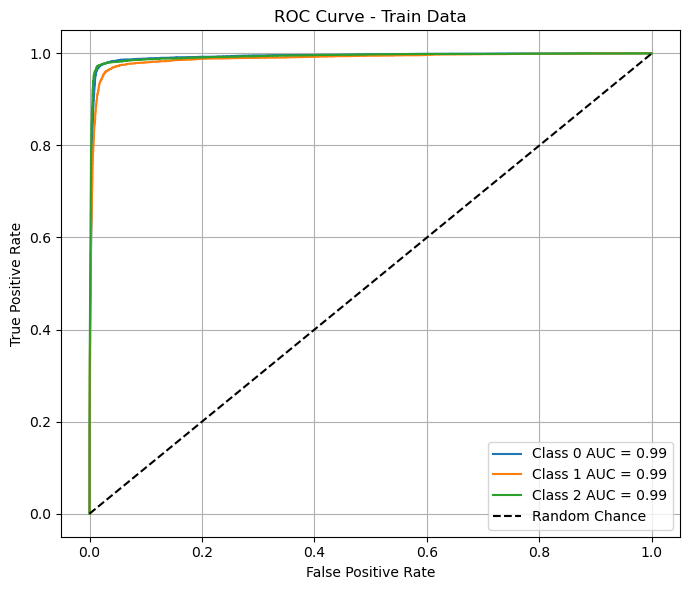

In [13]:
# Plot ROC Curve (One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_train_cat[:, i], y_train_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} AUC = {roc_auc[i]:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title("ROC Curve - Train Data")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Testing Data Check

In [14]:
# Predict on testing data
y_test_true = np.argmax(y_test_cat, axis=1)  # Ground truth labels
y_test_pred_probs = model.predict(X_test_pad)  # Probabilities
y_test_pred = np.argmax(y_test_pred_probs, axis=1)  # Predicted labels

# Confusion Matrix
conf_matrix_test = confusion_matrix(y_test_true, y_test_pred)

# F1 Score from classification report
report_test = classification_report(y_test_true, y_test_pred, output_dict=True)
f1_positive_test = report_test.get("2", {}).get("f1-score", 0.0)
f1_negative_test = report_test.get("0", {}).get("f1-score", 0.0)

# Accuracy
test_accuracy = np.mean(y_test_pred == y_test_true)

# AUC Score (macro average)
auc_score_test = roc_auc_score(y_test_cat, y_test_pred_probs, multi_class='ovr', average='macro')

# Print Metrics Summary
print("\nEvaluation Summary of testing data")
print(f"F1 Score (Positive): {f1_positive_test:.4f}")
print(f"F1 Score (Negative): {f1_negative_test:.4f}")
print(f"Testing Accuracy   : {test_accuracy:.4f}")
print(f"AUC Score          : {auc_score_test:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

Evaluation Summary of testing data
F1 Score (Positive): 0.7878
F1 Score (Negative): 0.7071
Testing Accuracy   : 0.7112
AUC Score          : 0.8785


In [15]:
print("confusion matrix ")
print(conf_matrix_test)

confusion matrix 
[[1306  613   81]
 [ 307 1452  241]
 [  81  410 1509]]


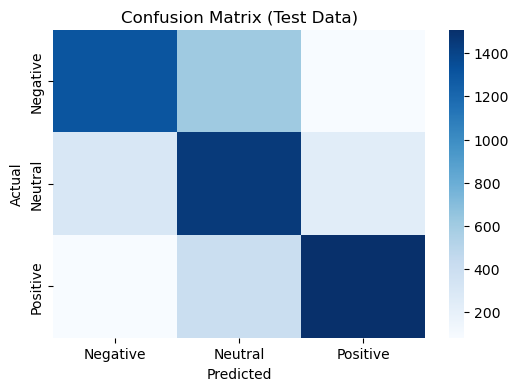

In [16]:
# Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_test, fmt='d', cmap='Blues', xticklabels=['Negative','Neutral','Positive'], yticklabels=['Negative','Neutral','Positive'])
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

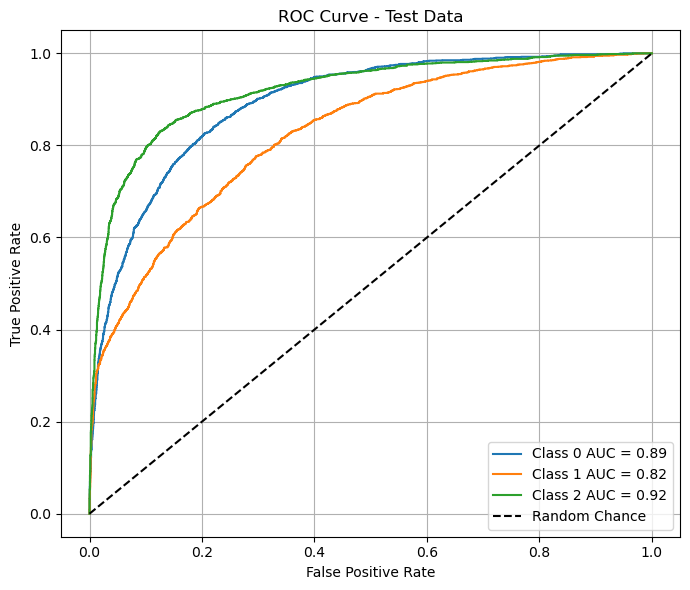

In [17]:
# Plot ROC Curve (Test Data, One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_test_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} AUC = {roc_auc[i]:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title("ROC Curve - Test Data")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

LLM Prompts used:
1. What is Bidirectional LSTM model ?
2. How to preprocess the tweet data for model building ?
3. Plot a graph for loss over epochs 